<div class="alert alert-block alert-success">
    <h1 align="center">Brain Tumor Segmentation</h1>
    <h3 align="center">Image Segmentation</h3>
    
<a href="https://www.kaggle.com/datasets/nikhilroxtomar/brain-tumor-segmentation">
About Dataset
    </a>
</div>

<img src="https://www.drmboyi.co.za/wp-content/uploads/2022/06/Dr-Mboyi-Blog-Templete-Brain-Cancer-1536x640.jpg" 
     style="width: 100%; max-width: 1200px; height: 280px; object-fit: cover; display: block; margin: 0 auto; border-radius: 8px;">

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to the Notebook...! 
    </h2>
    <p style="text-align: justify; margin-bottom: 20px;">
This notebook presents the development of a deep learning model for **brain tumor segmentation** in MRI scans. Using a U-Net-based architecture, we aim to automatically and accurately delineate tumor regions from medical images, assisting radiologists in faster and more precise diagnosis.
    </p>
<p style="text-align: justify; margin-bottom: 20px;">
Manual tumor segmentation by radiologists is a time-consuming and labor-intensive task that is also prone to inter-observer variability and human error. Deep learning models, particularly those based on U-Net, have shown remarkable potential in supporting clinicians by providing consistent, pixel-level segmentation, ultimately improving diagnostic efficiency and treatment planning.
</p>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        Project Overview & Implemented Pipeline:
    </p>
    <ul style="margin:0;padding-left:35px; text-align: justify; padding-top: 10px;">
        <li style="margin-bottom:14px;">Exploratory Data Analysis (EDA): Comprehensive analysis of the dataset including image visualization, tumor size distribution, and mask coverage to understand the inherent challenges of medical imaging.</li>
        <li style="margin-bottom:14px;">Preprocessing & Augmentation: Images were resized, normalized, and strongly augmented using geometric and photometric transformations to enhance model robustness and generalization.</li>
        <li style="margin-bottom:14px;">Model Architecture: A 'U-Net' with 'ResNet50' backbone pretrained on ImageNet, chosen for its powerful feature extraction capabilities and balance between performance and efficiency.</li>
        <li style="margin-bottom:14px;">Hybrid Loss Function: A carefully weighted combination of Binary Cross Entropy (BCE) and Dice Loss to effectively handle class imbalance and improve segmentation overlap.</li>
        <li style="margin-bottom:14px;">Evaluation Metrics: Monitored using 'Dice Coefficient' and 'IoU (Intersection over Union)' for a reliable and clinically relevant assessment of model performance.</li>
        <li style="margin-bottom:14px;">Visualization: Clear side-by-side comparisons of original MRI scans, ground truth masks, and model predictions to qualitatively evaluate results.</li>
    </ul>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Install required libraries
    </p>
</div>

In [1]:
!pip install -q keras_unet_collection
!pip install -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.1 MB/s eta 0:00:00


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Import required libraries
    </p>
</div>

In [2]:
import os, random, math
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
#---
import numpy as np
import cv2 as cv
from PIL import Image
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
#---
from keras_unet_collection import models
from tensorflow import keras
import tensorflow as tf
#---
import albumentations as A
#---
import warnings
warnings.filterwarnings('ignore')

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.2 Paths & quick inspect
    </p>
</div>

In [3]:
DATA_ROOT = '/kaggle/input/datasets/nikhilroxtomar/brain-tumor-segmentation'  
images_dir = os.path.join(DATA_ROOT, 'images')
masks_dir  = os.path.join(DATA_ROOT, 'masks')

print(f"Images exists: {os.path.exists(images_dir)}")
print(f"Masks exists: {os.path.exists(masks_dir)}")
sample_images = glob(f"{images_dir}/*.png")[:9]
sample_masks = glob(f"{masks_dir}/*.png")[:9]
print("Sample images count:", len(sample_images))
print("Sample masks count:", len(sample_masks))

Images exists: True
Masks exists: True
Sample images count: 9
Sample masks count: 9


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       2. Data Prepration
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify; font-weight:bold;">
            <li>
             Dataset Loading and Path Configuration
         </li>
        </ul>
</div>

In [4]:
BATCH_SIZE = 32
IMG_SIZE   = (256, 256)
AUTOTUNE = tf.data.AUTOTUNE
#---
image_paths = sorted(glob(f"{images_dir}/*.png"))
mask_paths  = sorted(glob(f"{masks_dir}/*.png"))

print("Images count:", len(image_paths))
print("Masks count: ", len(mask_paths))
#---
assert len(image_paths) == len(mask_paths)


Images count: 3064
Masks count:  3064


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Create Dataset and Split Data
         </li>
        </ul>
</div>


In [5]:
dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
total = len(image_paths)

train_size = int(0.8 * total)
val_size   = int(0.1 * total)

train_paths = dataset.take(train_size).shuffle(buffer_size=train_size, seed=SEED)
val_paths   = dataset.skip(train_size).take(val_size)
test_paths  = dataset.skip(train_size + val_size)

I0000 00:00:1783057990.513230      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Load image-Mask, Preprocessing And Augmentation Function:
         </li>
        </ul>
</div>

In [6]:
def load_image_mask(image_path, mask_path):
    #Read Images
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    #Read Masks
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)  
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')  
    mask = tf.cast(mask > 127, tf.float32)

    return image, mask
    
#--- Data Augmentation
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
])
#--- Data Augmentation Functation
def augment(image, mask):
    def aug_fn(image, mask):
        data = train_transform(image=image.numpy(), mask=mask.numpy())
        return data["image"], data["mask"]

    image, mask = tf.py_function(aug_fn, [image, mask], [tf.float32, tf.float32])
    image.set_shape((256, 256, 3))
    mask.set_shape((256, 256, 1))
    return image, mask

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Building tf.data Pipeline with Batching and Prefetching
         </li>
        </ul>
</div>

In [7]:
train_data = (train_paths
              .map(load_image_mask, num_parallel_calls=AUTOTUNE)
              .map(augment, num_parallel_calls=AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(AUTOTUNE))

val_data = (val_paths
            .map(load_image_mask, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_data = (test_paths
            .map(load_image_mask, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print(f"Train batches : {len(train_data)}")
print(f"Validation batches : {len(val_data)}")
print(f"Test batches : {len(test_data)}")

Train batches : 77
Validation batches : 10
Test batches : 10


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       3. EDA Analisys
    </p>
</div>


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Tumor Size Distribution
         </li>
        </ul>
</div>

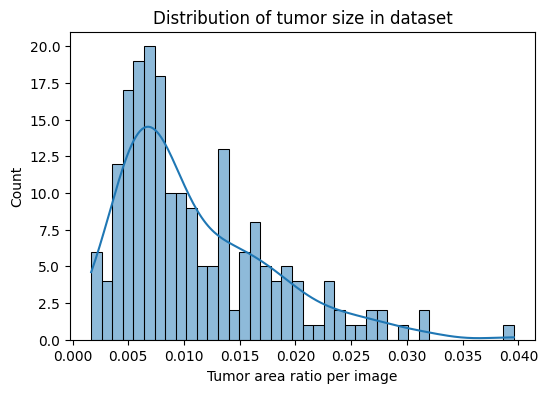

Mean tumor coverage: 1.10%


In [8]:
tumor_pixels = []
for m in mask_paths[:200]:  
    mask = np.array(Image.open(m).convert("L"))
    mask_bin = (mask > 0).astype(np.uint8)
    ratio = mask_bin.sum() / mask_bin.size
    tumor_pixels.append(ratio)

plt.figure(figsize=(6,4))
sns.histplot(tumor_pixels, bins=40, kde=True)
plt.xlabel("Tumor area ratio per image")
plt.ylabel("Count")
plt.title("Distribution of tumor size in dataset")
plt.show()

print(f"Mean tumor coverage: {np.mean(tumor_pixels)*100:.2f}%")


<div
    style="
        background-color: #DCFBFC;
        border-left: 6px solid #10B8BC;
        padding: 15px 20px;
        border-radius: 8px;
        margin: 15px 0;
        font-size: 14px;
        line-height: 1.5;
    "
>
    <p style="font-weight: bold; margin-bottom: 10px;">
        Description:
    </p>
    <ul style="margin: 0; padding-left: 20px; text-align: justify;">
        <li>
To better understand the dataset, we computed the tumor area ratio for each image, defined as the fraction of tumor pixels relative to the total number of pixels in the corresponding segmentation mask.
        </li>
        <li>
The histogram below shows the distribution of tumor sizes across the sampled images. Most tumors occupy only a small portion of the image (typically less than 1%), while only a few samples contain relatively large tumors, resulting in a right-skewed distribution.
        </li>
        <li>
The average tumor coverage is approximately 1.10%, indicating a significant class imbalance between tumor and background pixels. This observation highlights the challenging nature of the dataset, as the tumor occupies only a small fraction of each image, making accurate segmentation more difficult.
        </li>
    </ul>
</div>



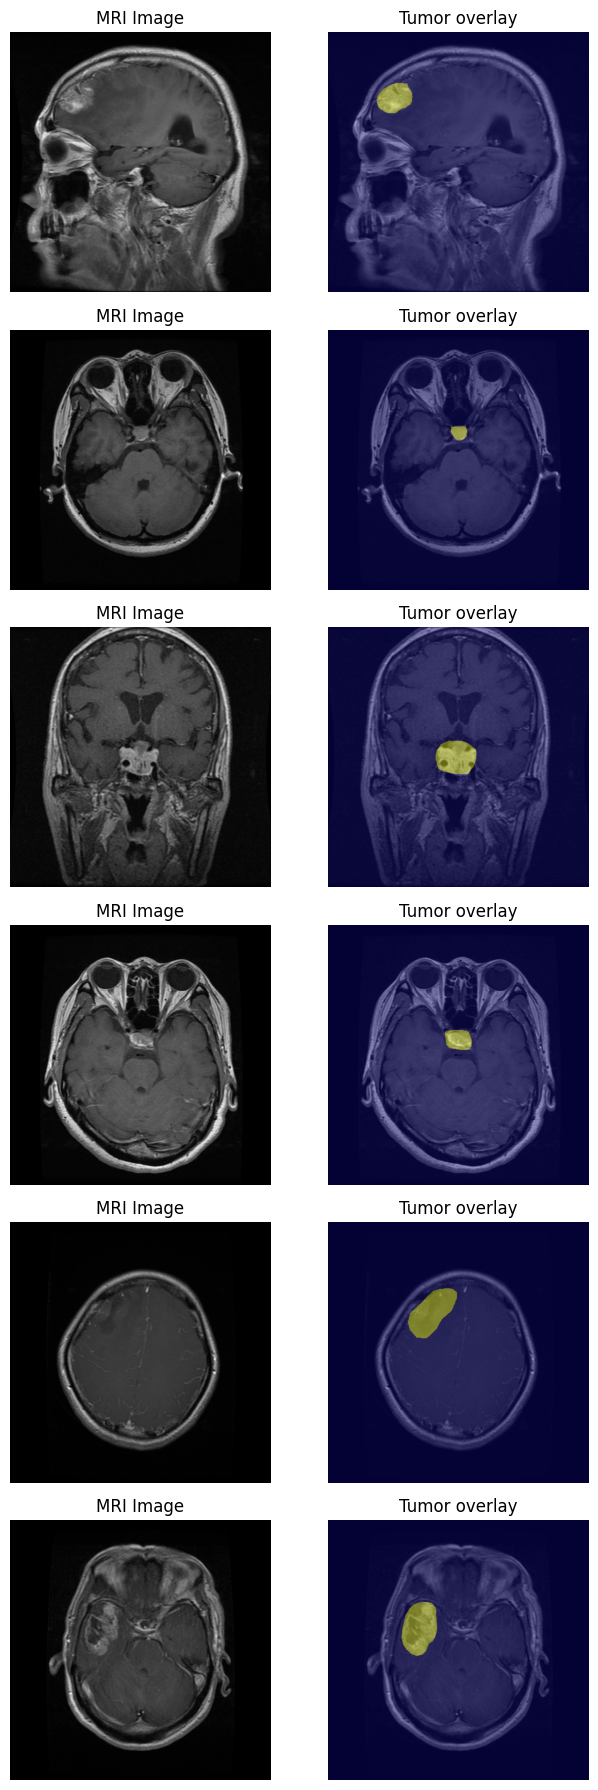

In [9]:
import random

rows, cols = 6, 2
fig, axs = plt.subplots(rows, cols, figsize=(7, 3*rows))

for i in range(rows):
    idx = random.randint(0, len(image_paths)-1)
    img = np.array(Image.open(image_paths[idx]).convert("RGB"))
    mask = np.array(Image.open(mask_paths[idx]).convert("L"))
    mask_bin = (mask > 127).astype(np.uint8)
    #MRI Image
    axs[i,0].imshow(img)
    axs[i,0].set_title("MRI Image")
    axs[i,0].axis("off")
    #Mask Image
    axs[i,1].imshow(img)
    axs[i,1].imshow(mask_bin, cmap="plasma" , alpha=0.4) 
    axs[i,1].set_title("Tumor overlay")
    axs[i,1].axis("off")

plt.tight_layout()
plt.show()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       4. Build Model
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Model, Loss, Optimizer, Metrics
         </li>
        </ul>
</div>

In [10]:
input_size = (256, 256, 3)
filter_num = [64, 128, 256, 512]
backbone = 'ResNet50'
weights = 'imagenet'
ACTIVATION = None
EPOCHS = 30
#---Unet Model:
model = models.unet_2d(
    input_size = input_size,
    filter_num = filter_num,
    n_labels=1,
    output_activation = ACTIVATION,         
    backbone = backbone,
    weights = weights,
    freeze_backbone = False,        
    freeze_batch_norm = False)


#--- Loss Functations
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_pred = tf.sigmoid(y_pred)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    dice = dice_loss(y_true, y_pred)   
    return 0.4 * bce(y_true, y_pred) + 0.6 * dice
    
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.sigmoid(y_pred)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)
    
#--- optimizer:
optimizer = keras.optimizers.AdamW(learning_rate=1e-4)

#--- Callbacks:
#Performance Learning:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1)

#Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_dice_coef',
    patience=10,
    restore_best_weights=True,
    mode='max')

callbacks = [lr_scheduler, early_stopping]


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Model Compilation And Training
         </li>
        </ul>
</div>

In [11]:
#Compile Model:
model.compile(
    optimizer=optimizer,
    loss=combined_loss,
    metrics=[dice_coef, iou_metric])  

#Fit Model:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks)


Epoch 1/30


I0000 00:00:1783058077.545072     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


76/77 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - dice_coef: 0.1207 - iou_metric: 0.0723 - loss: 0.5978

2026-07-03 05:56:04.774053: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 05:56:05.035886: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.1227 - iou_metric: 0.0736 - loss: 0.5962

2026-07-03 05:57:01.076607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 05:57:01.337997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


77/77 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - dice_coef: 0.2764 - iou_metric: 0.1748 - loss: 0.4754 - val_dice_coef: 1.0873e-08 - val_iou_metric: 5.4513e-09 - val_loss: 0.7325 - learning_rate: 1.0000e-04
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - dice_coef: 0.5638 - iou_metric: 0.3951 - loss: 0.2877 - val_dice_coef: 4.6073e-05 - val_iou_metric: 2.3037e-05 - val_loss: 0.6744 - learning_rate: 1.0000e-04
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - dice_coef: 0.6288 - iou_metric: 0.4606 - loss: 0.2446 - val_dice_coef: 1.0143e-06 - val_iou_metric: 5.0717e-07 - val_loss: 0.7012 - learning_rate: 1.0000e-04
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - dice_coef: 0.6614 - iou_metric: 0.4957 - loss: 0.2236 - val_dice_coef: 4.6266e-07 - val_iou_metric: 2.3134e-07 - val_loss: 0.7080 - learning_rate: 1.0000e-04
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.6863 - iou_metric: 0.5244 - loss: 0.2069
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.9999998736

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Training History & Final Metrics Evaluation
         </li>
        </ul>
</div>

Train Loss: 0.12357862293720245
Val Loss: 0.07287565618753433
______________________________
Val IOU : 0.796210765838623
Val Dice Coef: 0.8845307230949402


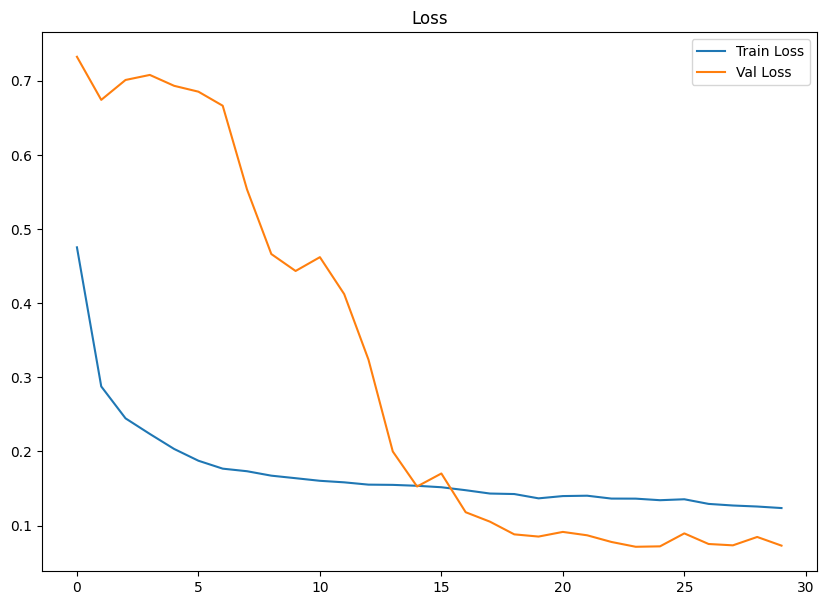

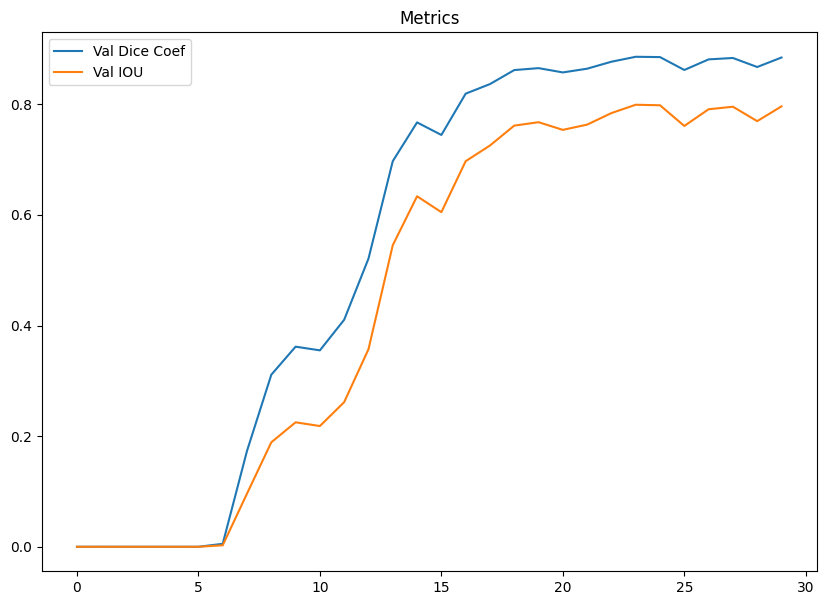

In [12]:
#print(history.history.keys())
print(f'Train Loss: {history.history['loss'][-1]}')
print(f'Val Loss: {history.history['val_loss'][-1]}')
#---
print('_'*30)
print(f'Val IOU : {history.history['val_iou_metric'][-1]}')
print(f'Val Dice Coef: {history.history['val_dice_coef'][-1]}')

#loss
plt.figure(figsize=(10,7))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

#IOU - Dice 
plt.figure(figsize=(10,7))
plt.plot(history.history['val_dice_coef'], label='Val Dice Coef')
plt.plot(history.history['val_iou_metric'], label='Val IOU')
plt.title('Metrics')
plt.legend()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
             Final Evaluation on Test Set
         </li>
        </ul>
</div>

In [15]:
results = model.evaluate(test_data, verbose=1)

print(f"Test Loss : {results[0]:.4f}")
print(f"Test Dice Coef : {results[1]:.4f}")
print(f"Test IoU  : {results[2]:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - dice_coef: 0.7603 - iou_metric: 0.6200 - loss: 0.1680
Test Loss : 0.1680
Test Dice Coef : 0.7603
Test IoU  : 0.6200


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       5. Visual Evaluation of Model Predictions
    </p>
</div>

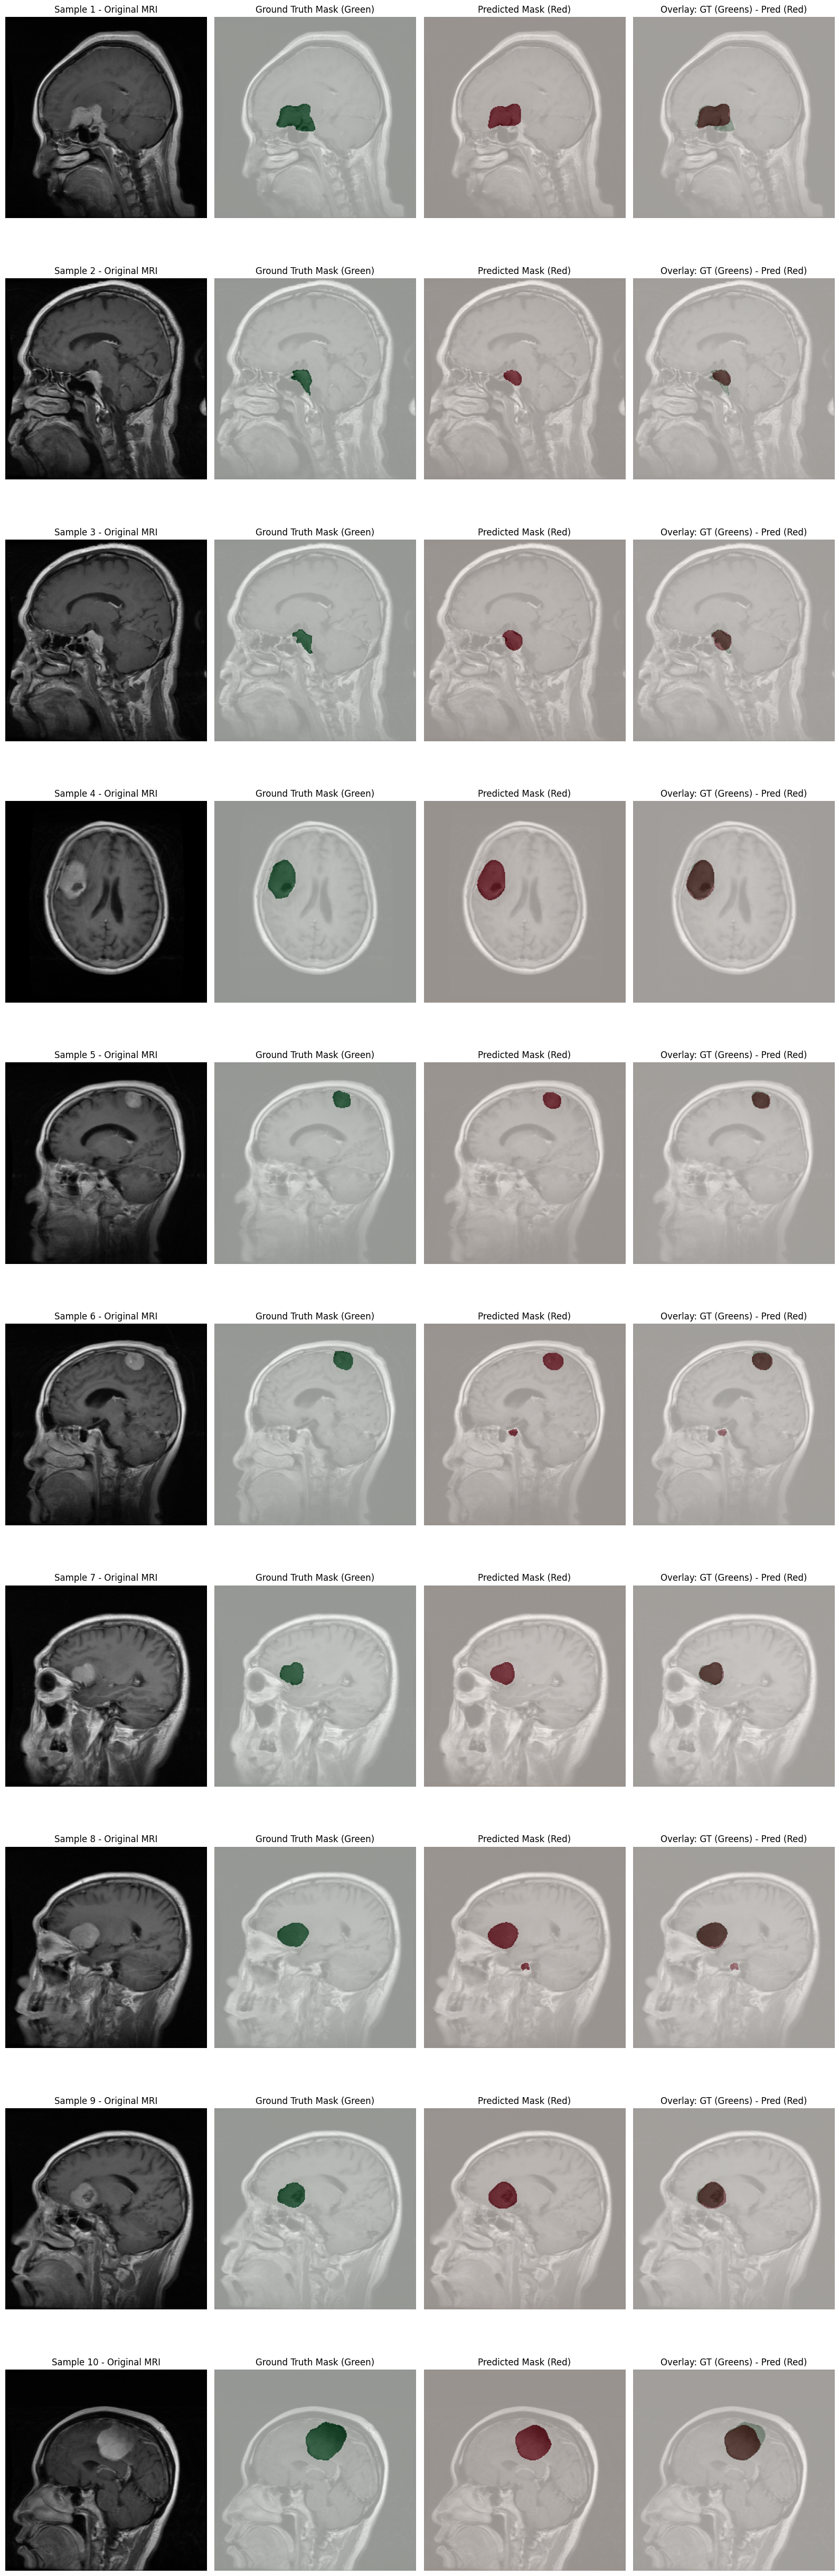

In [24]:
#---Visualization Function
def visualize_predictions(model, dataset, num_samples=10):
    plt.figure(figsize=(16, 5*num_samples))
    
    for i, (image, mask_true) in enumerate(dataset.unbatch().take(num_samples)):

        pred = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
        pred = tf.sigmoid(pred).numpy() > 0.5   
        pred = pred.squeeze()                   
        
        image_np = image.numpy()
        mask_true_np = mask_true.numpy().squeeze()
        
        #---Row Plot
        plt.subplot(num_samples, 4, i*4 + 1)
        plt.imshow(image_np)
        plt.title(f"Sample {i+1} - Original MRI")
        plt.axis('off')
        
        # Ground Truth Mask
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(image_np)
        plt.imshow(mask_true_np, cmap='Greens', alpha=0.6)
        plt.title("Ground Truth Mask (Green)")
        plt.axis('off')
        
        # Prediction Mask
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(image_np)
        plt.imshow(pred, cmap='Reds', alpha=0.6)
        plt.title("Predicted Mask (Red)")
        plt.axis('off')
        
        # Overlay Both Masks
        plt.subplot(num_samples, 4, i*4 + 4)
        plt.imshow(image_np)
        plt.imshow(mask_true_np, cmap='Greens', alpha=0.4)   
        plt.imshow(pred, cmap='Reds', alpha=0.4)            
        plt.title("Overlay: GT (Greens) - Pred (Red)")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
#---

visualize_predictions(model, val_data, num_samples=10)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
    </p>
</div>